# Importations

In [39]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Auxiliary python functions
from itertools import combinations

# Local importations
from moments.bloch import (compute_pauli_basis, compute_tensor_basis, compute_subset_index_map,
                           compute_bloch_vector, compute_bloch_norms_from_dm)

## Moments vs. sector lengths

Sector lengths are defined as

$$
S_k (\varrho) = \sum_{\substack{\vec \jmath = 0 \\ \mathrm{wt}(\vec \jmath) = k}}^{d^2 - 1} T_{\vec \jmath}^2
$$

where $\vec \jmath$ represents the tupple of indices of the pauli basis $\vec{\jmath} \equiv (j_i, j_2, \ldots, j_N)$.

The marginal second order moments of $\varrho$ over a partition $Q$ of the system are defined as

$$
\mathcal{R}^{(2)} \left(\varrho_Q\right) = \sum_{\vec \jmath_Q = 1}^{d^2 - 1} T_{\vec \jmath_Q}^2
$$

where $\varrho_Q$ is the reduced state of $\varrho$ over partition $Q$, and $\vec \jmath_Q$ is the vector $\vec \jmath$ where the only non-zero indices are the ones corresponding to the qubits on partition $Q$. With this formulation, the sector length can be rewritten as:

$$
S_{k} (\varrho) = \sum_{\substack{Q \\ |Q| = k}} \mathcal{R}^{(2)} \left(\varrho_Q\right)
$$

so that the sum runs over all possible partitions of $k$ parties. For a system of $N$ qubits, this is $\binom{k}{N}$, so that $\sum_{k = 0}^{N} \binom{k}{N} = 2^{N}$.

- Since the computation of $S_k (\varrho)$ is through $\mathcal{R}^{(2)} \left(\varrho_Q\right)$, to obtain bot sets of quantities $\left\{ S_k \right\}$ and $\left\{ \mathcal{R}_Q^{(2)} \right\}$ is equally efficcient.
- Moreover, since second order moments are invariant under LU tranformation, and all partitions $\varrho_Q$ are valid quantum systems, then any $\mathcal{R}_Q^{(2)}$ is LU invariant.
- What is more important, $\mathcal{R}_Q^{(2)}$ is able to parametrize entanglement better than $S_k$. This is because when performing the sum, we are loosing information about the different partitions, and many systems become equivalent, for example different permutations of partitions and states with different entanglement classes. Nevertheless, $\mathcal{R}_Q^{(2)}$ preserves that information and it both characterizes the correlations between particles and identifies between which particles the correlations occur.

| Property | $\left\{ S_k^{(2)} \right\}$ | $\left\{ S_k^{(3)} \right\}$ | $\left\{ \mathcal{R}_Q^{(2)} \right\}$ |
|---|---|---|---|
|Parametrizes entanglemet| Yes | ? | Yes |
|Differentiates between entanglement classes| No | ? | ? |
|Invariant under LU| Yes | No | Yes |
|Computed through random measurements| Yes | No | Yes |
|Number of measurements|$2^{N}$|$4^{N}$|$2^{N}$|
|Convolutional propety| Yes | Yes | - |
|Number of parameters| $N$ | $N$ | $2^{N}$ |

# Definitions

In [4]:
def adj(A: np.ndarray) -> np.ndarray:
    return np.conj(A).T

def compute_outer_product(psi: np.ndarray, phi: np.ndarray) -> np.ndarray:
    if psi.shape != phi.shape:
        raise ValueError("psi and phi must have the same shape.")
    if len(psi.shape) != 2 or psi.shape[1] != 1:
        raise ValueError("psi and phi must be column vectors of shape (d, 1).")
    return psi @ adj(phi)

def compute_GHZ_state(N: int) -> np.ndarray:
    if N <= 0:
        return np.zeros((2**max(0, N), 1), dtype=complex)
    GHZ = np.zeros((2**N, 1), dtype=complex)
    GHZ[0, 0] = 1
    GHZ[2**N - 1, 0] = 1
    return GHZ / np.sqrt(2)

# $\mathcal{R}^{(2)}_{Q}$ for some examples of states

$$
\varrho_{\mathrm{sep}} = | + \rangle \langle + | = \frac12 (\sigma_0 + \sigma_1)
$$

In [25]:
dn, N = 2, 1
dim = [dn] * N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

psi_sep = compute_GHZ_state(1)
rho_sep = compute_outer_product(psi_sep, psi_sep)

R = compute_bloch_norms_from_dm(tensor_basis, subset_index_map, rho_sep)

for key, value in R.items():

    print(f"{key}: {value**2:.2f}")

(1,): 1.00



$$
\varrho_{\mathrm{Bell}} = | \phi_2^+ \rangle \langle \phi_2^+ | = \frac{1}{2} (\sigma_{00} + \sigma_{11} - \sigma_{22} + \sigma_{33})
$$

In [ ]:
dn, N = 2, 2
dim = [dn] * N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

psi_bell = compute_GHZ_state(2)
rho_bell = compute_outer_product(psi_bell, psi_bell)

R = compute_bloch_norms_from_dm(tensor_basis, subset_index_map, rho_bell)

for key, value in R.items():

    print(f"{key}: {value**2:.2f}")

(1,): 0.00
(2,): 0.00
(1, 2): 3.00


$$
\varrho = \varrho_{\mathrm{Sep}} \otimes \varrho_{\mathrm{Bell}} = \frac{1}{4}(\sigma_{00} + \sigma_{11} - \sigma_{22} + \sigma_{33}) \otimes (\sigma_0 + \sigma_1) =
$$
$$
\frac{1}{4}(\sigma_{000} + \sigma_{001} + \sigma_{110} - \sigma_{220} + \sigma_{330} + \sigma_{111}  - \sigma_{221} + \sigma_{331})

$$

In [31]:
dn, N = 2, 3
dim = [dn] * N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

rho = np.kron(rho_bell, rho_sep)

R = compute_bloch_norms_from_dm(tensor_basis, subset_index_map, rho)

for key, value in R.items():

    print(f"{key}: {value**2:.2f}")

(1,): 0.00
(2,): 0.00
(3,): 1.00
(1, 2): 3.00
(1, 3): 0.00
(2, 3): 0.00
(1, 2, 3): 3.00


$$
\varrho = \varrho_{\mathrm{Bell}} \otimes \varrho_{\mathrm{Bell}} = \frac{1}{4} (\sigma_{00} + \sigma_{11} - \sigma_{22} + \sigma_{33}) \otimes (\sigma_{00} + \sigma_{11} - \sigma_{22} + \sigma_{33})
$$

In [32]:
dn, N = 2, 4
dim = [dn] * N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

rho = np.kron(rho_bell, rho_bell)

R = compute_bloch_norms_from_dm(tensor_basis, subset_index_map, rho)

for key, value in R.items():

    print(f"{key}: {value**2:.2f}")

(1,): 0.00
(2,): 0.00
(3,): 0.00
(4,): 0.00
(1, 2): 3.00
(1, 3): 0.00
(1, 4): 0.00
(2, 3): 0.00
(2, 4): 0.00
(3, 4): 3.00
(1, 2, 3): 0.00
(1, 2, 4): 0.00
(1, 3, 4): 0.00
(2, 3, 4): 0.00
(1, 2, 3, 4): 9.00


$$
\varrho_{\mathrm{GHZ}} = | \phi_4^+ \rangle \langle \phi_4^+ | = 
$$
$$
\frac{1}{4}(\hat{\sigma}_{0000} + \hat{\sigma}_{0033} + \hat{\sigma}_{0303} + \hat{\sigma}_{0330} + \hat{\sigma}_{1111} - \hat{\sigma}_{1122} - \hat{\sigma}_{1212} - \hat{\sigma}_{1221} - \hat{\sigma}_{2112} - \hat{\sigma}_{2121} - \hat{\sigma}_{2211} + \hat{\sigma}_{2222} + \hat{\sigma}_{3003} + \hat{\sigma}_{3030} + \hat{\sigma}_{3300} + \hat{\sigma}_{3333})
$$

In [33]:
dn, N = 2, 4
dim = [dn] * N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

psi_GHZ = compute_GHZ_state(4)
rho_GHZ = compute_outer_product(psi_GHZ, psi_GHZ)

R = compute_bloch_norms_from_dm(tensor_basis, subset_index_map, rho_GHZ)

for key, value in R.items():

    print(f"{key}: {value**2:.2f}")

(1,): 0.00
(2,): 0.00
(3,): 0.00
(4,): 0.00
(1, 2): 1.00
(1, 3): 1.00
(1, 4): 1.00
(2, 3): 1.00
(2, 4): 1.00
(3, 4): 1.00
(1, 2, 3): 0.00
(1, 2, 4): 0.00
(1, 3, 4): 0.00
(2, 3, 4): 0.00
(1, 2, 3, 4): 9.00


# $k$-separability differentiation of $\mathcal{R}^{(2)}_Q$ 

In [35]:
dn, N = 2, 4
dim = [dn] * N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

In [47]:
psi = [compute_GHZ_state(n) for n in range(1, N+1)]
rho = [compute_outer_product(psi_n, psi_n) for psi_n in psi]

RHO = [
    np.kron(rho[0], np.kron(rho[0], np.kron(rho[0], rho[0]))),
    np.kron(rho[1], np.kron(rho[0], rho[0])),
    np.kron(rho[1], rho[1]),
    np.kron(rho[2], rho[0]),
    rho[3]
]

R = [compute_bloch_norms_from_dm(tensor_basis, subset_index_map, phi) for phi in RHO]

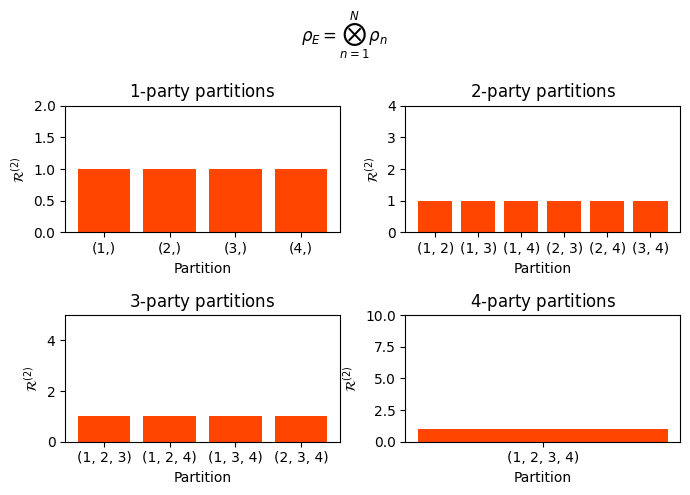

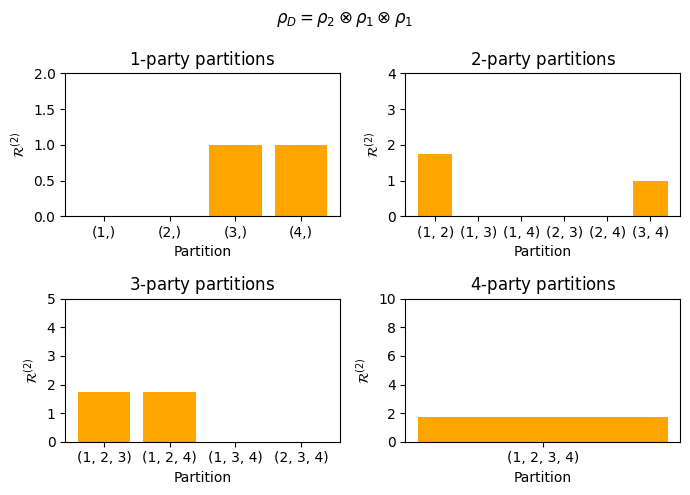

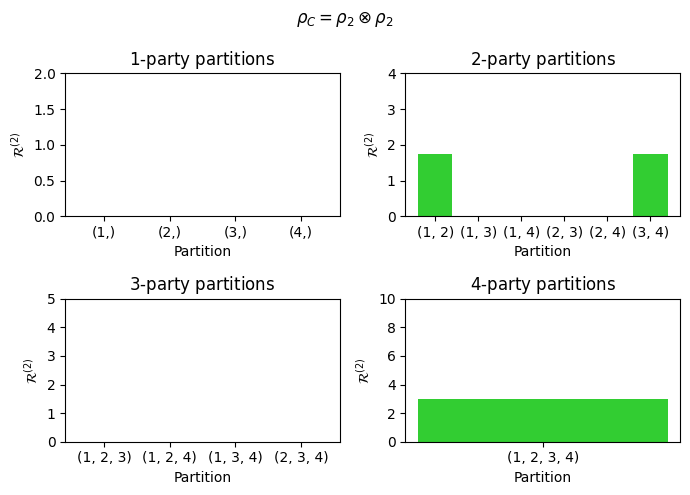

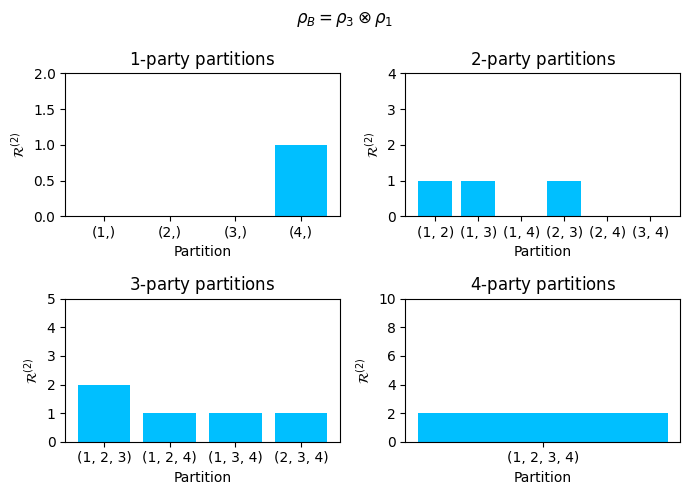

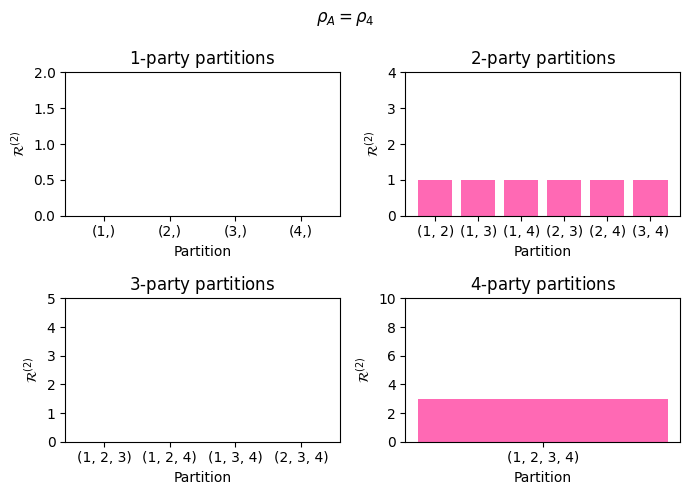

In [67]:
N = 4
    
labels = [
    r"$\rho_{E} = \bigotimes_{n = 1}^{N} \rho_{n}$",
    r"$\rho_{D} = \rho_{2} \otimes \rho_{1} \otimes \rho_{1}$",
    r"$\rho_{C} = \rho_{2} \otimes \rho_{2}$",
    r"$\rho_{B} = \rho_{3} \otimes \rho_{1}$",
    r"$\rho_{A} = \rho_{4}$",
    ]
colors = ["orangered", "orange", "limegreen", "deepskyblue", "hotpink"]

grouped_subsets = {r: list(combinations(range(1, N + 1), r)) for r in range(1, N + 1)}

for k, r in enumerate(R):

    fig, ax = plt.subplots(2, 2, figsize = (7, 5))

    for i, axi in enumerate(ax.flat):
        xi, yi = range(len(grouped_subsets[i + 1])), [r[subsets] for subsets in grouped_subsets[i + 1]]
        axi.bar(xi, yi, color = colors[k])
        axi.set(xlabel = "Partition", ylabel = r"$\mathcal{R}^{(2)}$",
                title = r"${}$-party partitions".format(i + 1),
                xticks = range(len(grouped_subsets[i + 1])), xticklabels = grouped_subsets[i + 1])
    
    ax[0, 0].set_ylim(0, 2)
    ax[0, 1].set_ylim(0, 4)
    ax[1, 0].set_ylim(0, 5)
    ax[1, 1].set_ylim(0, 10)

    fig.suptitle(labels[k])
    fig.tight_layout()
    plt.show()